In [ ]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
from gtbook.display import show
from gtsam.symbol_shorthand import X, L
from gtsam import symbolChr, symbolIndex
import gtsam.utils.plot as gtsam_plot
from utilities.utils import kstr


### Create factor graph

In [150]:
gfg = gtsam.GaussianFactorGraph() # gaussian factor graph

X1 = X(1)
X2 = X(2)
X3 = X(3)
pose_vars = [X1, X2, X3]

L1 = L(1)
L2 = L(2)
landmark_vars = [L1, L2]

all_vars = pose_vars + landmark_vars

priorMean = gtsam.Point2(0.0, 0.0) # np.array([0.0, 0.0])
priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2]))

odometry = gtsam.Point2(2.0, 0.0) # np.array([2.0, 0.0])
odometryNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1]))

gfg.add(gtsam.JacobianFactor(X1, np.eye(2), priorMean, priorNoise))
gfg.add(gtsam.JacobianFactor(X1, -np.eye(2), X2, np.eye(2), odometry, odometryNoise))
gfg.add(gtsam.JacobianFactor(X2, -np.eye(2), X3, np.eye(2), odometry, odometryNoise))

measurement_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1]))
measurement_X1_L1 = gtsam.Point2(2.0, 2.0) # np.array([1.0, 1.0])
measurement_X2_L1 = gtsam.Point2(0.0, 2.0) # np.array([-1.0, -1.0])
measurement_X3_L2 = gtsam.Point2(0.0, 2.0) # np.array([-1.0, -1.0])

gfg.add(gtsam.JacobianFactor(X1, -np.eye(2), L1, np.eye(2), measurement_X1_L1, measurement_noise))
gfg.add(gtsam.JacobianFactor(X2, -np.eye(2), L1, np.eye(2), measurement_X2_L1, measurement_noise))
gfg.add(gtsam.JacobianFactor(X3, -np.eye(2), L2, np.eye(2), measurement_X3_L2, measurement_noise))

### Optimization

In [153]:
solution = gfg.optimize()

print(f"solution = {solution} with error {gfg.error(solution)}")

l1 = gtsam.Point2(solution.at(L1))
l2 = gtsam.Point2(solution.at(L2))

l1.between(l2)
#solution_dense = gfg.optimizeDensely()
#print(f"solution_dense = {solution_dense} with error {gfg.error(solution_dense)}")

solution = VectorValues: 5 elements
  l1: 2.0000 2.0000
  l2: 4.0000 2.0000
  x1: 0.0000 0.0000
  x2: 2.0000 0.0000
  x3: 4.0000 0.0000
 with error 1.1036368979703967e-28


AttributeError: 'numpy.ndarray' object has no attribute 'between'

### Covariances

The $d$ below is the "square root information vector", as the Bayes net defines the following quadratic, and corresponding Gaussian density, in this case in $\mathbb{R}^6$:

$$
E_{gbn}(x; R, d) \doteq \frac{1}{2} \|Rx - d\|^2
$$

$$
\mathcal{N}_{gbn}(x; R, d) \sim k \exp \{- \frac{1}{2} \|Rx - d\|^2\}
$$

In [144]:
# Convert to Gaussian Bayes Net
gbn = gfg.eliminateSequential()
#show(gbn)

R, d = gbn.matrix() # Suquare root information matrix (R) and vector (d)
information_matrix = R.T @ R
covariance_matrix = np.linalg.inv(R.T @ R) 

#### Covariance Computation Methods in GTSAM

There are two common ways to obtain covariance matrices from a factor graph:

1. **From the Hessian (Information Form)**  
   - The factor graph can be expressed in canonical Gaussian form  
     $
     E(x) = \tfrac{1}{2} x^\top \Lambda x - x^\top \eta + \text{const},
     $  
     where $\Lambda = P^{-1}$ is the **information matrix**.  
   - Calling `gfg.hessian()` constructs this global information matrix \(\Lambda\).  
   - Inverting it yields the full covariance:  
     $
     P_{\text{information}} = \Lambda^{-1}.
     $  
   - Marginal covariances of subsets of variables can then be obtained by slicing the corresponding blocks of $P_{\text{information}}$.  
   - **Advantage:** straightforward, gives full covariance.  
   - **Disadvantage:** requires inverting the entire information matrix (expensive for large problems).  

2. **From Marginalization (Elimination-Based)**  
   - The `Marginals` class computes covariances by **eliminating variables** in the factor graph (e.g., via Cholesky factorization).  
   - This allows extracting only the covariance for a subset of variables without forming the entire $P$.  
   - Calling `marginals.marginalCovariance(key)` gives the covariance for one variable.  
   - Calling `marginals.jointMarginalCovariance(keys)` gives the joint covariance matrix for a set of variables.  
   - **Advantage:** efficient for subsets; avoids computing the full inverse.  
   - **Disadvantage:** requires repeated queries if many different marginals are needed.  

---

**Key Point:** Both methods give the *same result mathematically*. The difference is purely in **how the computation is carried out**:  
- **Hessian inversion:** global, dense, expensive.  
- **Marginals API:** local, on-demand, efficient.  


In [145]:
# Marginals object
marginals = gtsam.Marginals(gfg, solution)

# Compute global covariance from Hessian
information_matrix, _ = gfg.hessian()
P_information = np.linalg.inv(information_matrix)
joint = marginals.jointMarginalCovariance(all_vars)
joint_cov = joint.fullMatrix()



### Comparing covariances

In [146]:
# Compare individual pose covariances
for i, key in enumerate(all_vars, start=1):
    cov_from_joint = joint.at(key, key)
    cov_from_marg = marginals.marginalCovariance(key)

    print(f"{kstr(key)}:")
    print("From full joint cov matrix:\n", cov_from_joint)
    print("From marginals:\n", cov_from_marg)
    print("Equal? ->", np.allclose(cov_from_joint, cov_from_marg, atol=1e-10))
    print("-"*50)

# Compare joint covariance (all poses together)
joint_cov = marginals.jointMarginalCovariance(all_vars).fullMatrix()
print("Joint covariance (marginals) vs. full inverse match? ->",
      np.allclose(joint_cov, P_information, atol=1e-8))
np.set_printoptions(precision=3, suppress=True)


X1:
From full joint cov matrix:
 [[0.04 0.  ]
 [0.   0.04]]
From marginals:
 [[0.04 0.  ]
 [0.   0.04]]
Equal? -> True
--------------------------------------------------
X2:
From full joint cov matrix:
 [[0.047 0.   ]
 [0.    0.047]]
From marginals:
 [[0.047 0.   ]
 [0.    0.047]]
Equal? -> True
--------------------------------------------------
X3:
From full joint cov matrix:
 [[0.057 0.   ]
 [0.    0.057]]
From marginals:
 [[0.057 0.   ]
 [0.    0.057]]
Equal? -> True
--------------------------------------------------
L1:
From full joint cov matrix:
 [[0.047 0.   ]
 [0.    0.047]]
From marginals:
 [[0.047 0.   ]
 [0.    0.047]]
Equal? -> True
--------------------------------------------------
L2:
From full joint cov matrix:
 [[0.067 0.   ]
 [0.    0.067]]
From marginals:
 [[0.067 0.   ]
 [0.    0.067]]
Equal? -> True
--------------------------------------------------
Joint covariance (marginals) vs. full inverse match? -> True


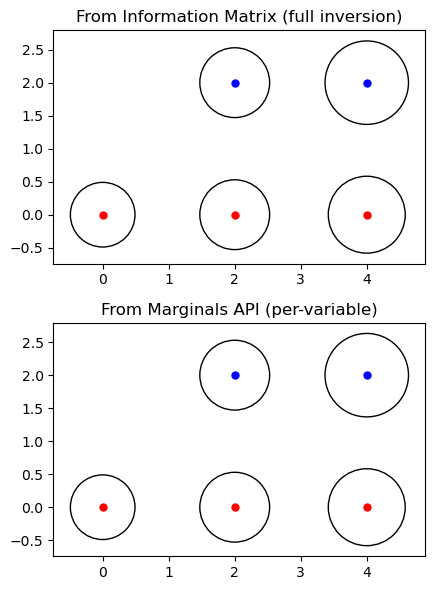

In [147]:
fig, axs = plt.subplots(2, 1, figsize=(22, 6))

for ax, title, cov_source in zip(
    axs,
    ["From Information Matrix (full inversion)", "From Marginals API (per-variable)"],
    ["joint", "marginals"]
):

    ax.set_aspect('equal')
    ax.set_title(title)

    for i, var in enumerate(all_vars, start=1):
        mean = solution.at(var)

        if cov_source == "joint":
            cov = joint.at(var, var)
        elif cov_source == "marginals":
            cov = marginals.marginalCovariance(var)

        if kstr(var)[0] == 'X':
            gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='r', P=cov)
        elif kstr(var)[0] == 'L':
            gtsam_plot.plot_point2_on_axes(ax, point=mean, linespec='b', P=cov)

plt.tight_layout()
plt.show()